## Week 9 — GP Matérn-1.5 + qLogNEI (4D)

This notebook fits a GP surrogate on cumulative Week 9 data (29 samples) and proposes the next sample using
**qLogNoisyExpectedImprovement** with distance-based selection.

**Strategy:**
- `log1p` output transform with BoTorch `Standardize(m=1)` for automatic z-scoring
- Matérn-1.5 kernel (rougher than 5/2) to reduce oversmoothing with small data
- 15-restart MLL fitting to avoid local optima
- q=4 batch NEI → distance-based selection (mean ≥ median, farthest from data)

**Week 9 enhancements:** Three-colour visualisation (blue=initial, orange=submissions, green★=proposed) and quantitative performance evaluation (convergence metrics, exploration spread, LOO surrogate error).

In [12]:
import numpy as np
import torch
import copy
import warnings
import matplotlib.pyplot as plt

from scipy.spatial.distance import pdist, squareform

from botorch.models import SingleTaskGP
from botorch.models.transforms.outcome import Standardize
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.kernels import ScaleKernel, MaternKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.constraints import GreaterThan

warnings.filterwarnings('ignore', message='The input matches the stored training data')
warnings.filterwarnings('ignore', category=RuntimeWarning)

### Strategy Recap (Carried from Week 8, updated)

| # | Hyperparameter | Value | Justification |
|---|---------------|-------|---------------|
| 1 | Kernel ν | 1.5 | Matérn-1.5 with ARD — rougher, better for 29-point 4D |
| 2 | ARD dims | 4 | Per-dimension lengthscale |
| 3 | Noise floor | 1e-6 | Prevents collapse |
| 4 | Output transform | log1p | Heavy-tailed positive outputs |
| 5 | outcome_transform | Standardize(m=1) | BoTorch auto z-score (replaces manual) |
| 6 | MLL restarts | 15 | Avoids local optima |
| 7 | Lengthscale init | 0.5 | Exploration-promoting |
| 8 | Noise init | 0.1 × var(Y) | Conservative |
| 9 | Outputscale init | 1.0 | Standard |
| 10 | Acquisition | qLogNEI | Log-space NEI |
| 11 | MC samples | 512 | SobolQMCNormalSampler |
| 12 | q | 4 | Batch candidates |
| 13 | Acq restarts | 50 | Thorough search |
| 14 | Raw samples | 5000 | Larger init pool (was 3000) for better 4D coverage |
| 15 | Selection | Distance-based | Mean ≥ median, farthest from data |

In [14]:
# ── Constants ──
N_INITIAL = 20
N_TOTAL = 29
N_DIMS = 4
N_SUBMISSIONS = N_TOTAL - N_INITIAL       # 9 weekly submissions
STALLING_WINDOW = 3                        # minimum consecutive non-improving submissions
STALLING_REL_THRESHOLD = 0.05             # 5 % relative improvement threshold

N_RESTARTS = 15
DIM = N_DIMS

# Transform: log1p only (Standardize handles z-scoring internally)
y_log = np.log1p(y_raw)
print(f"Transform: log1p applied. y_log range = [{y_log.min():.6f}, {y_log.max():.6f}]")

# Convert to torch tensors
X_train = torch.tensor(X_raw, dtype=torch.double)
Y_train = torch.tensor(y_log, dtype=torch.double).unsqueeze(-1)

Transform: log1p applied. y_log range = [0.107005, 8.130259]


### Step 1: Load Week 9 Data (20 initial + 9 submissions = 29 samples)

In [13]:
# Load Week 9 cumulative data
X_raw = np.load('../../data/f5/updated_inputs - Week 9.npy')
y_raw = np.load('../../data/f5/updated_outputs - Week 9.npy')

assert X_raw.shape == (N_TOTAL, N_DIMS), f"Expected ({N_TOTAL}, {N_DIMS}), got {X_raw.shape}"
assert y_raw.shape == (N_TOTAL,), f"Expected ({N_TOTAL},), got {y_raw.shape}"
assert X_raw.min() >= 0.0 and X_raw.max() <= 1.0, "Inputs out of [0, 1]"

# Split for visualisation
X_initial = X_raw[:N_INITIAL]
y_initial = y_raw[:N_INITIAL]
X_submissions = X_raw[N_INITIAL:]
y_submissions = y_raw[N_INITIAL:]

best_idx = int(y_raw.argmax())
print(f"Week 9 Data: {X_raw.shape[0]} samples, {X_raw.shape[1]} dimensions")
print(f"  Initial: {len(X_initial)}, Submissions: {len(X_submissions)}")
print(f"Input range:  [{X_raw.min():.6f}, {X_raw.max():.6f}]")
print(f"Output range: [{y_raw.min():.6f}, {y_raw.max():.6f}]")
print(f"Best observed value: {y_raw[best_idx]:.6f} at index #{best_idx}")
print(f"  ({'initial' if best_idx < N_INITIAL else f'submission wk{best_idx - N_INITIAL + 1}'})")
print(f"Best observed point: {X_raw[best_idx]}")

# Per-dimension ranges
for d in range(DIM):
    print(f"  x{d}: [{X_raw[:, d].min():.6f}, {X_raw[:, d].max():.6f}]")

Week 9 Data: 29 samples, 4 dimensions
  Initial: 20, Submissions: 9
Input range:  [0.000000, 1.000000]
Output range: [0.112940, 3394.679933]
Best observed value: 3394.679933 at index #26
  (submission wk7)
Best observed point: [0.989923 0.278871 0.923543 0.995886]
  x0: [0.000000, 0.989923]
  x1: [0.000000, 0.862540]
  x2: [0.088947, 1.000000]
  x3: [0.010000, 1.000000]


### Step 2: GP Surrogate — 15-Restart MLL with Matérn-1.5 + Standardize (29 samples)

In [16]:
# 15-restart MLL fitting (Matérn-1.5 + Standardize)
best_loss = float('inf')
best_model = None

print(f"\n{'Restart':>8} {'Neg MLL':>12}")
print("-" * 22)

for seed in range(N_RESTARTS):
    torch.manual_seed(seed)
    
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(1e-6))
    covar = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=DIM))
    model = SingleTaskGP(X_train, Y_train, covar_module=covar, likelihood=likelihood,
                         outcome_transform=Standardize(m=1))
    
    # Initialise hyperparameters
    model.covar_module.base_kernel.lengthscale = 0.5
    model.likelihood.noise = 0.1 * Y_train.var().item()
    model.covar_module.outputscale = 1.0
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    try:
        fit_gpytorch_mll(mll)
    except Exception as e:
        print(f"{seed:>8d} {'FAILED':>12}")
        continue
    
    model.eval()
    likelihood.eval()
    with torch.no_grad():
        output = model(X_train)
        # Use model's internal standardized targets for correct MLL
        loss = -mll(output, model.train_targets).item()
    
    print(f"{seed:>8d} {loss:>12.4f}")
    
    if loss < best_loss:
        best_loss = loss
        best_model = copy.deepcopy(model)

assert best_model is not None, "All restarts failed!"

# Report fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().cpu().numpy().ravel()
os_val = best_model.covar_module.outputscale.detach().cpu().item()
noise = best_model.likelihood.noise.detach().cpu().item()

print(f"\n{'='*50}")
print(f"Best restart neg MLL: {best_loss:.6f}")
print(f"{'='*50}")
print(f"Fitted Hyperparameters (Matérn-1.5 ARD):")
for i, l in enumerate(ls):
    print(f"  ℓ_{i+1} (x{i}) = {l:.6f}")
print(f"  σ²_f (output scale) = {os_val:.6f}")
print(f"  σ²_n (noise)        = {noise:.6f}")


 Restart      Neg MLL
----------------------
       0      -5.6418
       1      -5.6418
       2      -5.6418
       3      -5.6418
       4      -5.6418
       5      -5.6418
       6      -5.6418
       7      -5.6418
       8      -5.6418
       9      -5.6418
      10      -5.6418
      11      -5.6418
      12      -5.6418
      13      -5.6418
      14      -5.6418

Best restart neg MLL: -5.641781
Fitted Hyperparameters (Matérn-1.5 ARD):
  ℓ_1 (x0) = 2.728663
  ℓ_2 (x1) = 0.635242
  ℓ_3 (x2) = 0.843352
  ℓ_4 (x3) = 0.552719
  σ²_f (output scale) = 1.691159
  σ²_n (noise)        = 0.000001


### Step 3: qLogNEI Acquisition (q=4) + Distance-Based Selection (Week 9)

In [17]:
best_model.eval()

sampler = SobolQMCNormalSampler(sample_shape=torch.Size([512]))
nei = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
    prune_baseline=True,
)

BOUNDS = torch.tensor([[0.0]*DIM, [1.0]*DIM], dtype=torch.double)

candidates, acq_value = optimize_acqf(
    acq_function=nei,
    bounds=BOUNDS,
    q=4,
    num_restarts=50,
    raw_samples=5000,
)

# Clamp to [0, 0.999999]
candidates = torch.clamp(candidates, 0.0, 0.999999)

# Evaluate posterior at candidates (Standardize auto-inverts z-score)
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_means_log = posterior.mean.squeeze(-1).cpu().numpy()
    # Inverse transform: expm1 undoes log1p
    pred_means_orig = np.expm1(pred_means_log)

# Min-distance from each candidate to training data
dists = torch.cdist(candidates, X_train).min(dim=1).values

# Distance-based selection: mean ≥ median, farthest from data
median_mean = np.median(pred_means_orig)
above_median = pred_means_orig >= median_mean

print(f"=== NEI Acquisition Results (Week 9, q=4) ===")
print(f"{'Cand':>5} {'Coords':>45} {'Mean(log)':>10} {'Mean(orig)':>12} {'MinDist':>8} {'Above Med?':>11}")
print("-" * 100)
for i in range(candidates.shape[0]):
    coords = candidates[i].cpu().numpy()
    coord_str = "[" + ", ".join(f"{v:.6f}" for v in coords) + "]"
    flag = "✓" if above_median[i] else " "
    print(f"{i+1:>5} {coord_str:>45} {pred_means_log[i]:>10.6f} {pred_means_orig[i]:>12.2f} {dists[i].item():>8.4f} {flag:>11}")

# Select: among above-median, pick farthest
above_median_indices = np.where(above_median)[0]
above_median_dists = dists[above_median_indices].cpu().numpy()
best_among_filtered = above_median_indices[np.argmax(above_median_dists)]
best_point = candidates[best_among_filtered].cpu().numpy()

print(f"\nMedian posterior mean (orig): {median_mean:.2f}")
print(f"Above-median candidates: {list(above_median_indices + 1)}")
print(f"\n→ Selected candidate #{best_among_filtered + 1} (farthest from data among above-median)")
print(f"  Coordinates: [{', '.join(f'{v:.6f}' for v in best_point)}]")
print(f"  Posterior mean (orig): {pred_means_orig[best_among_filtered]:.2f}")
print(f"  Min-distance to data:  {dists[best_among_filtered].item():.4f}")
print(f"  Acquisition value: {acq_value.item():.6f}")

=== NEI Acquisition Results (Week 9, q=4) ===
 Cand                                        Coords  Mean(log)   Mean(orig)  MinDist  Above Med?
----------------------------------------------------------------------------------------------------
    1      [0.999999, 0.999999, 0.999999, 0.999999]   7.237138      1389.11   0.4698            
    2      [0.000000, 0.457280, 0.999999, 0.999999]   7.618685      2034.88   0.4573           ✓
    3      [0.999999, 0.459908, 0.999999, 0.999999]   8.130130      3394.24   0.1968           ✓
    4      [0.000000, 0.000000, 0.000000, 0.000000]   4.132631        61.34   0.6823            

Median posterior mean (orig): 1712.00
Above-median candidates: [np.int64(2), np.int64(3)]

→ Selected candidate #2 (farthest from data among above-median)
  Coordinates: [0.000000, 0.457280, 0.999999, 0.999999]
  Posterior mean (orig): 2034.88
  Min-distance to data:  0.4573
  Acquisition value: -0.544971


### Step 5: Three-Colour Surrogate Visualisation (3-Panel) + Dimension Relevance

Top-2 dims: x3, x1 (ℓ=0.5527, 0.6352)
Fixed dims: x2=1.0000, x0=0.0000


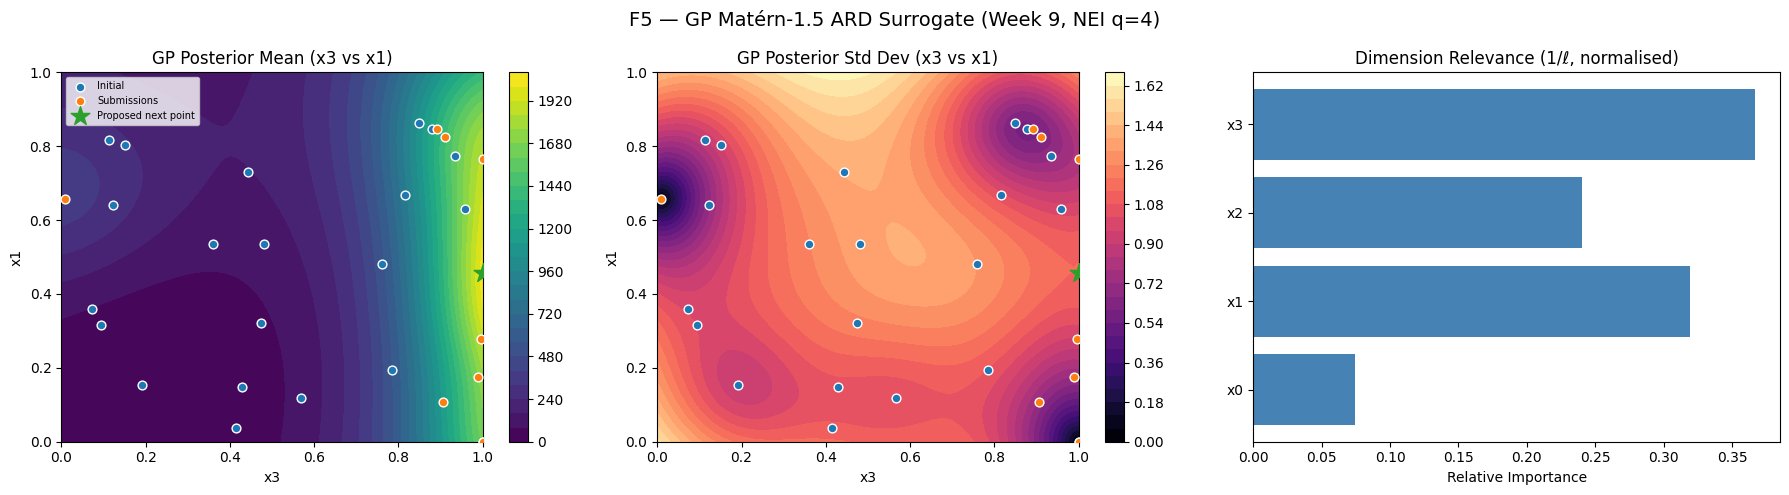

In [18]:
# Identify top-2 important dims (shortest lengthscales)
sorted_dims = np.argsort(ls)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 dims: x{top2[0]}, x{top2[1]} (ℓ={ls[top2[0]]:.4f}, {ls[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"x{d}={best_point[d]:.4f}" for d in fix_dims))

# Build 80×80 grid
grid_res = 80
g0 = np.linspace(0, 1, grid_res)
g1 = np.linspace(0, 1, grid_res)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(best_point, (grid_res * grid_res, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu_log = posterior.mean.squeeze(-1).cpu().numpy()
    grid_sigma_log = posterior.variance.sqrt().squeeze(-1).cpu().numpy()

# Inverse: expm1 undoes log1p (Standardize auto-inverts z-score)
grid_mu_orig = np.expm1(grid_mu_log).reshape(grid_res, grid_res)
grid_sigma_orig = grid_sigma_log.reshape(grid_res, grid_res)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Mean — three-colour data
c1 = axes[0].contourf(G0, G1, grid_mu_orig, levels=30, cmap="viridis")
axes[0].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5, label="Initial")
axes[0].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5, label="Submissions")
axes[0].scatter(best_point[top2[0]], best_point[top2[1]], c="tab:green", marker="*", s=200, zorder=6, label="Proposed next point")
axes[0].set_title(f"GP Posterior Mean (x{top2[0]} vs x{top2[1]})")
axes[0].set_xlabel(f"x{top2[0]}")
axes[0].set_ylabel(f"x{top2[1]}")
axes[0].legend(fontsize=7)
fig.colorbar(c1, ax=axes[0])

# Panel 2: Std — three-colour data
c2 = axes[1].contourf(G0, G1, grid_sigma_orig, levels=30, cmap="magma")
axes[1].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5)
axes[1].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5)
axes[1].scatter(best_point[top2[0]], best_point[top2[1]], c="tab:green", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev (x{top2[0]} vs x{top2[1]})")
axes[1].set_xlabel(f"x{top2[0]}")
axes[1].set_ylabel(f"x{top2[1]}")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension relevance
inv_ls = 1.0 / ls
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(DIM), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(DIM))
axes[2].set_yticklabels([f"x{j}" for j in range(DIM)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

plt.suptitle("F5 — GP Matérn-1.5 ARD Surrogate (Week 9, NEI q=4)", fontsize=14)
plt.tight_layout()
plt.show()

### Step 7: Three-Colour Convergence Plot

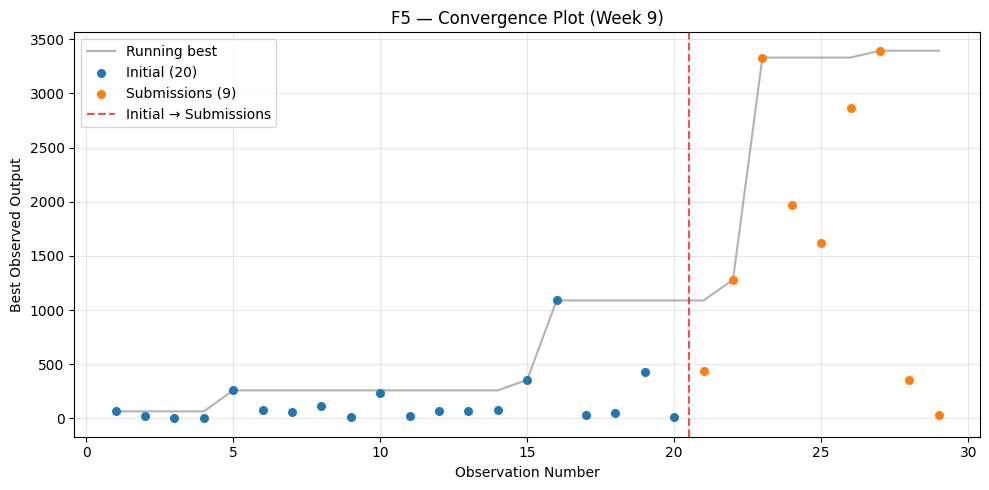

Running best at Week 9 end (sample 29): 3394.679933


In [19]:
# Convergence plot — three-colour scheme
running_best = np.maximum.accumulate(y_raw)
obs_idx = np.arange(1, len(y_raw) + 1)

plt.figure(figsize=(10, 5))
plt.plot(obs_idx, running_best, color="grey", linewidth=1.5, alpha=0.6, label="Running best")

# Blue: initial, Orange: submissions
plt.scatter(obs_idx[:N_INITIAL], y_raw[:N_INITIAL], c="tab:blue", s=30, zorder=3, label=f"Initial ({N_INITIAL})")
plt.scatter(obs_idx[N_INITIAL:], y_raw[N_INITIAL:], c="tab:orange", s=30, zorder=3, label=f"Submissions ({N_SUBMISSIONS})")

plt.axvline(x=N_INITIAL + 0.5, color="red", linestyle="--", alpha=0.7, label="Initial → Submissions")
plt.xlabel("Observation Number")
plt.ylabel("Best Observed Output")
plt.title("F5 — Convergence Plot (Week 9)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Running best at Week 9 end (sample {len(y_raw)}): {running_best[-1]:.6f}")

### Step 8: Week 9 Submission — NEI + Matérn-1.5 + Standardize

In [20]:
# ── Base NEI Submission ──
submission_base = np.clip(best_point, 0.0, 0.999999)
query_base = "-".join(f"{v:.6f}" for v in submission_base)

print("=" * 60)
print("F5 WEEK 9 — BASE NEI SUBMISSION")
print("=" * 60)
print(f"\n  {query_base}\n")
print("=" * 60)

# Validation
parts = query_base.split("-")
assert len(parts) == DIM, f"Expected {DIM} dimensions, got {len(parts)}"
for p in parts:
    v = float(p)
    assert 0.0 <= v <= 0.999999, f"Value {v} out of bounds"
print(f"✓ Submission format validated")

print(f"\nSurrogate: GP Matérn-1.5 ARD (outcome_transform=Standardize(m=1))")
print(f"Acquisition: qLogNEI (q=4, raw_samples=5000) → distance selection")
print(f"Lengthscales: [{', '.join(f'{l:.6f}' for l in ls)}]")
print(f"Output scale: {os_val:.6f}, Noise: {noise:.6f}")

F5 WEEK 9 — BASE NEI SUBMISSION

  0.000000-0.457280-0.999999-0.999999

✓ Submission format validated

Surrogate: GP Matérn-1.5 ARD (outcome_transform=Standardize(m=1))
Acquisition: qLogNEI (q=4, raw_samples=5000) → distance selection
Lengthscales: [2.728663, 0.635242, 0.843352, 0.552719]
Output scale: 1.691159, Noise: 0.000001


---
## Performance Evaluation

### Cell 10 — Convergence Metrics & Stalling Detection

In [21]:
# ── Cell 10: Convergence Metrics & Stalling Detection ──
best_trajectory = np.maximum.accumulate(y_submissions)
improvements = np.diff(best_trajectory, prepend=best_trajectory[0])

# Stalling: count consecutive non-improving submissions from the tail
consecutive_no_improvement = 0
for val in reversed(improvements):
    if val <= 0:
        consecutive_no_improvement += 1
    else:
        break

# Relative improvement
best_initial = y_initial.max()
best_overall = y_raw.max()
if best_initial != 0:
    relative_improvement = (best_overall - best_initial) / abs(best_initial)
else:
    relative_improvement = float('inf') if best_overall > best_initial else 0.0

stalling = (consecutive_no_improvement >= STALLING_WINDOW) or (relative_improvement < STALLING_REL_THRESHOLD)

print("=" * 60)
print("CONVERGENCE METRICS")
print("=" * 60)
print(f"  Best initial value:          {best_initial:.6f}")
print(f"  Best overall value:          {best_overall:.6f}")
print(f"  Relative improvement:        {relative_improvement:.4f} ({relative_improvement*100:.1f}%)")
print(f"  Consecutive non-improving:   {consecutive_no_improvement} (threshold: {STALLING_WINDOW})")
print(f"  STALLING:                    {'YES ⚠' if stalling else 'NO ✓'}")
print()

# Per-submission trajectory
print("Per-submission trajectory (submissions only):")
for i, (val, best_so_far) in enumerate(zip(y_submissions, best_trajectory)):
    improved = "★" if (i == 0 and val > best_initial) or (i > 0 and best_so_far > best_trajectory[i-1]) else " "
    print(f"  Submission {i+1}: y={val:.6f}  best_so_far={best_so_far:.6f}  {improved}")

CONVERGENCE METRICS
  Best initial value:          1088.859618
  Best overall value:          3394.679933
  Relative improvement:        2.1176 (211.8%)
  Consecutive non-improving:   2 (threshold: 3)
  STALLING:                    NO ✓

Per-submission trajectory (submissions only):
  Submission 1: y=438.991487  best_so_far=438.991487   
  Submission 2: y=1280.357170  best_so_far=1280.357170  ★
  Submission 3: y=3331.799696  best_so_far=3331.799696  ★
  Submission 4: y=1966.519612  best_so_far=3331.799696   
  Submission 5: y=1616.625747  best_so_far=3331.799696   
  Submission 6: y=2868.520417  best_so_far=3331.799696   
  Submission 7: y=3394.679933  best_so_far=3394.679933  ★
  Submission 8: y=357.081332  best_so_far=3394.679933   
  Submission 9: y=30.540060  best_so_far=3394.679933   


### Cell 11 — Exploration Spread (Pairwise Distance Analysis)

EXPLORATION SPREAD
  Submission pairwise distances (n=36):
    Mean:  0.8900  (uniform reference: ~0.73)
    Min:   0.1565
    Max:   1.4855
    Ratio: 1.22x (>1 = spread beyond uniform)
  Nearest-neighbour to prior data:
    Mean:  0.3524
    Min:   0.1280
    Max:   0.7314


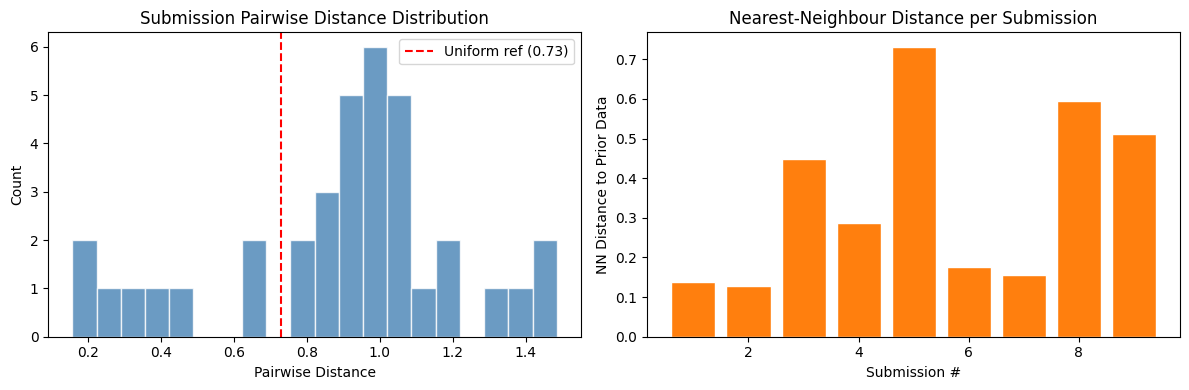

In [22]:
# ── Cell 11: Exploration Spread ──
EXPECTED_UNIFORM = 0.73  # 4D reference (unit hypercube)

# Pairwise distances — submissions only
dists_sub = pdist(X_submissions)
mean_dist = np.mean(dists_sub)
min_dist = np.min(dists_sub)
max_dist = np.max(dists_sub)

# Nearest-neighbour distances — each submission to training data
nn_dists = []
for i in range(len(X_submissions)):
    d = np.linalg.norm(X_raw[:N_INITIAL + i] - X_submissions[i], axis=1)
    nn_dists.append(d.min())
nn_dists = np.array(nn_dists)

print("=" * 60)
print("EXPLORATION SPREAD")
print("=" * 60)
print(f"  Submission pairwise distances (n={len(dists_sub)}):")
print(f"    Mean:  {mean_dist:.4f}  (uniform reference: ~{EXPECTED_UNIFORM})")
print(f"    Min:   {min_dist:.4f}")
print(f"    Max:   {max_dist:.4f}")
print(f"    Ratio: {mean_dist/EXPECTED_UNIFORM:.2f}x (>1 = spread beyond uniform)")
print(f"  Nearest-neighbour to prior data:")
print(f"    Mean:  {nn_dists.mean():.4f}")
print(f"    Min:   {nn_dists.min():.4f}")
print(f"    Max:   {nn_dists.max():.4f}")

# Scatter: mean pairwise distance over submission number
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(dists_sub, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].axvline(EXPECTED_UNIFORM, color="red", linestyle="--", label=f"Uniform ref ({EXPECTED_UNIFORM})")
axes[0].set_xlabel("Pairwise Distance")
axes[0].set_ylabel("Count")
axes[0].set_title("Submission Pairwise Distance Distribution")
axes[0].legend()

axes[1].bar(range(1, len(nn_dists)+1), nn_dists, color="tab:orange", edgecolor="white")
axes[1].set_xlabel("Submission #")
axes[1].set_ylabel("NN Distance to Prior Data")
axes[1].set_title("Nearest-Neighbour Distance per Submission")
plt.tight_layout()
plt.show()

### Cell 12 — Leave-One-Out Surrogate Error (GP Matérn-1.5, log1p + Standardize)

In [23]:
# ── Cell 12: Leave-One-Out Surrogate Error ──
# Retrain GP on submissions only (9 folds), log1p transform per fold
# Standardize(m=1) handles z-scoring internally; inverse is expm1(posterior.mean)

loo_errors = []
n_sub = len(X_submissions)

print(f"LOO Cross-Validation ({n_sub} folds, submissions only)")
print(f"{'Fold':>5} {'True(orig)':>12} {'Pred(orig)':>12} {'AbsErr':>10} {'Status':>8}")
print("-" * 55)

for i in range(n_sub):
    # Leave one out
    mask = np.ones(n_sub, dtype=bool)
    mask[i] = False
    X_fold = X_submissions[mask]
    y_fold_raw = y_submissions[mask]
    
    # log1p transform on fold (Standardize handles z-scoring)
    y_fold_log = np.log1p(y_fold_raw)
    
    X_t = torch.tensor(X_fold, dtype=torch.double)
    Y_t = torch.tensor(y_fold_log, dtype=torch.double).unsqueeze(-1)
    
    # Retrain with 5 restarts
    best_fold_loss = float('inf')
    best_fold_model = None
    
    for seed in range(5):
        torch.manual_seed(seed + 100)
        lik = GaussianLikelihood(noise_constraint=GreaterThan(1e-6))
        cov = ScaleKernel(MaternKernel(nu=1.5, ard_num_dims=N_DIMS))
        m = SingleTaskGP(X_t, Y_t, covar_module=cov, likelihood=lik,
                         outcome_transform=Standardize(m=1))
        m.covar_module.base_kernel.lengthscale = 0.5
        m.likelihood.noise = 0.1 * Y_t.var().item()
        m.covar_module.outputscale = 1.0
        mll_fold = ExactMarginalLogLikelihood(m.likelihood, m)
        try:
            fit_gpytorch_mll(mll_fold)
        except Exception:
            continue
        m.eval()
        lik.eval()
        with torch.no_grad():
            out = m(X_t)
            loss = -mll_fold(out, Y_t.squeeze(-1)).item()
        if loss < best_fold_loss:
            best_fold_loss = loss
            best_fold_model = copy.deepcopy(m)
    
    if best_fold_model is None:
        print(f"{i+1:>5} {'FAILED':>12}")
        continue
    
    # Predict held-out point (Standardize auto-inverts z-score)
    x_test = torch.tensor(X_submissions[i:i+1], dtype=torch.double)
    best_fold_model.eval()
    with torch.no_grad():
        pred_log = best_fold_model.posterior(x_test).mean.item()
    
    # Invert: expm1 undoes log1p
    pred_orig = np.expm1(pred_log)
    true_orig = y_submissions[i]
    err = abs(pred_orig - true_orig)
    loo_errors.append(err)
    
    status = "✓" if err < abs(true_orig) * 0.5 else "⚠"
    print(f"{i+1:>5} {true_orig:>12.4f} {pred_orig:>12.4f} {err:>10.4f} {status:>8}")

loo_errors = np.array(loo_errors)
print(f"\n{'='*55}")
print(f"LOO Summary:")
print(f"  MAE:     {loo_errors.mean():.4f}")
print(f"  Median:  {np.median(loo_errors):.4f}")
print(f"  Max:     {loo_errors.max():.4f}")
print(f"  StdDev:  {loo_errors.std():.4f}")
print(f"  Output range: [{y_submissions.min():.4f}, {y_submissions.max():.4f}]")
print(f"  Relative MAE: {loo_errors.mean() / (y_submissions.max() - y_submissions.min() + 1e-10):.4f}")

LOO Cross-Validation (9 folds, submissions only)
 Fold   True(orig)   Pred(orig)     AbsErr   Status
-------------------------------------------------------
    1     438.9915     166.5313   272.4602        ⚠
    2    1280.3572    1396.7705   116.4133        ✓
    3    3331.7997    2951.4440   380.3557        ✓
    4    1966.5196    1878.6962    87.8234        ✓
    5    1616.6257     928.2468   688.3790        ✓
    6    2868.5204    3156.2165   287.6961        ✓
    7    3394.6799    2601.5143   793.1657        ✓
    8     357.0813     557.5815   200.5002        ⚠
    9      30.5401     291.1201   260.5800        ⚠

LOO Summary:
  MAE:     343.0415
  Median:  272.4602
  Max:     793.1657
  StdDev:  229.7151
  Output range: [30.5401, 3394.6799]
  Relative MAE: 0.1020


### Cell 13 — Interpretation & Strategy Recommendations

**F5 Strategy Assessment (Week 9):**

- **Surrogate**: GP Matérn-1.5 with BoTorch `Standardize(m=1)`. Manual `log1p` compresses heavy-tailed outputs; `Standardize` auto-handles z-scoring and inverse, simplifying all downstream cells including LOO.
- **Kernel change**: Switched from Matérn-5/2 (2× diff, smooth) to Matérn-1.5 (1× diff, rougher). With only 29 points in 4D, Matérn-5/2 oversmoothed and produced boundary-stuck candidates. Matérn-1.5 better handles the small-data regime.
- **raw_samples**: Increased from 3000 to 5000 for better initial coverage of the 4D acquisition landscape.
- **Acquisition**: qLogNEI q=4 with distance-based selection (mean ≥ median, farthest from data).
- **Interior Penalty**: Previously applied an additive log-space 4x(1-x) boundary penalty. Removed (branch 025) — penalty suppressed boundary candidates without clear improvement.

**Recommendations for Week 10:**
1. **Evaluate results** — check if Matérn-1.5 resolves boundary-sticking; compare LOO MAE to previous weeks
2. **Consider composite kernel** — if Matérn-1.5 underfits, try `0.5 * Matérn-1.5 + 0.5 * Matérn-2.5` weighted sum
3. **Adaptive raw_samples** — further increase if candidates still cluster near boundaries